# Trabalho Final: Modelo Neural - Cães e Gatos - Utilizando PCA e TSNE

Implementação de um modelo neural que, com base no dataset, as classifica em cães e gatos utilizando técnicas de PCA e TSNE

Trabalho Final - RNA

Isabella Mariana Cardoso Pinto - RA: 164915

José Vanderlei da Silva Júnior - RA: 163851

Katherine Mombach van den Mosselaar - RA: 163873

## Importando dados - Início código

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import Model
import keras.datasets as kds

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.image import imread

print(tf.__version__)
!nvidia-smi -L

2.18.0
GPU 0: Tesla T4 (UUID: GPU-a5fbcef6-4b90-29b5-a2aa-6e17a8c39fc5)


O código abaixo foi baseado no caderno Colab disponível em:
https://github.com/google/eng-edu/tree/main/ml/pc/exercises


## Carregamento do Modelo Inception V3

In [ ]:
from tensorflow.keras.applications import InceptionV3, ResNet50V2

inception = InceptionV3(
    input_shape=(299, 299, 3), include_top=True, weights="imagenet")


96112376/96112376 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Parâmetro: `include_top=False` informa que as camadas densas finais não devem ser carregadas. Utilizado quando queremos usar o modelo como um extrator de características e não um classificador

## Congelamento das Camadas (extrator)

In [ ]:
for layer in inception.layers:
  layer.trainable = False


In [ ]:
last_layer = inception.get_layer('avg_pool')
# last_layer = inception.get_layer('mixed7')

print('Dimensões da última camada da rede:', last_layer.output.shape)
last_output = last_layer.output

Dimensões da última camada da rede: (None, 2048)


## Construção do Modelo (Classificação Binária)

In [ ]:
# Flattening da última camada convolucional
# Saída do camada conv 3D --> vetor (1D)
x = layers.Flatten()(last_output)
# Camada densa com 512 neurônios - capturar padrões abstratos e não lineares
x = layers.Dense(512, activation='relu')(x)


# Criação do modelo:
# Mantém a parte convolucional da Inception e substitui a cabeça original
# (camadas superiores) por novas camadas totalmente conectadas
modelo4 = Model(inception.input, x)

modelo4.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['acc'])

## Carga do dataset Cats & Dogs

In [ ]:
!wget --no-check-certificate \
   https://storage.googleapis.com/mledu-datasets/cats_and_dogs_filtered.zip -O \
   /tmp/cats_and_dogs_filtered.zip

--2025-05-11 17:21:05--  https://storage.googleapis.com/mledu-datasets/cats_and_dogs_filtered.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 64.233.170.207, 142.251.175.207, 74.125.24.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|64.233.170.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 68606236 (65M) [application/zip]
Saving to: ‘/tmp/cats_and_dogs_filtered.zip’

/tmp/cats_and_dogs_ 100%[===================>]  65.43M  20.3MB/s    in 4.1s    

2025-05-11 17:21:10 (16.1 MB/s) - ‘/tmp/cats_and_dogs_filtered.zip’ saved [68606236/68606236]



## Preparação do conjunto para treinamento

In [ ]:
import os
import zipfile

from tensorflow.keras.preprocessing.image import ImageDataGenerator

local_zip = '/tmp/cats_and_dogs_filtered.zip'
zip_ref = zipfile.ZipFile(local_zip, 'r')
zip_ref.extractall('/tmp')
zip_ref.close()

# Define our example directories and files
base_dir = '/tmp/cats_and_dogs_filtered'
train_dir = os.path.join(base_dir, 'train')
validation_dir = os.path.join(base_dir, 'validation')

# Directory with our training cat pictures
train_cats_dir = os.path.join(train_dir, 'cats')

# Directory with our training dog pictures
train_dogs_dir = os.path.join(train_dir, 'dogs')

# Directory with our validation cat pictures
validation_cats_dir = os.path.join(validation_dir, 'cats')

# Directory with our validation dog pictures
validation_dogs_dir = os.path.join(validation_dir, 'dogs')

train_cat_fnames = os.listdir(train_cats_dir)
train_dog_fnames = os.listdir(train_dogs_dir)

### Exemplo Imagens Cachorros

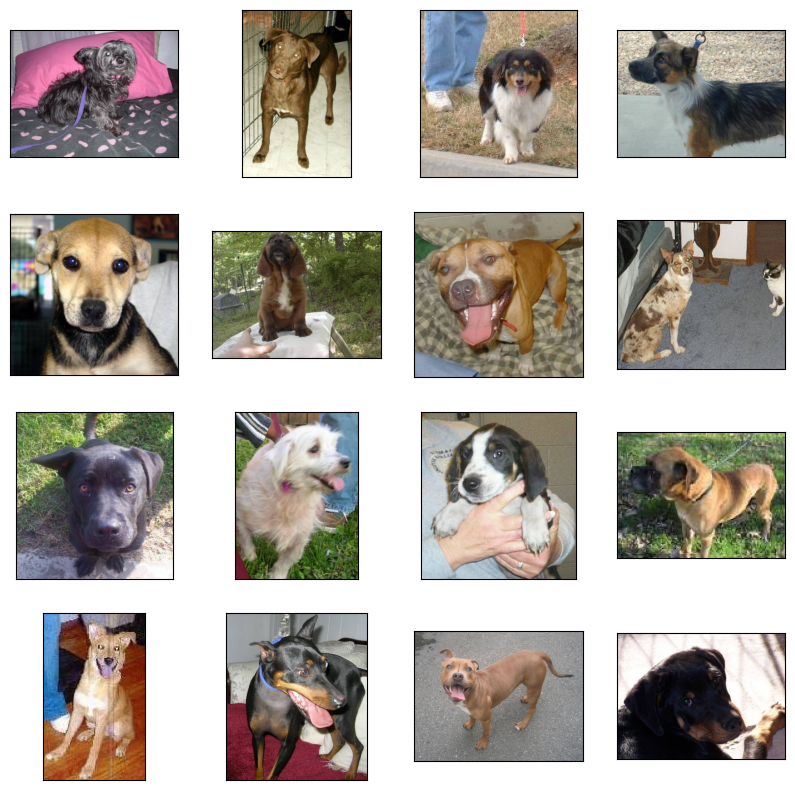

In [ ]:
# Imagens de Cachorros
plt.figure(figsize=(10, 10))
for i in range(16):
  ax = plt.subplot(4, 4, i + 1)
  filename = train_dogs_dir + '/dog.' + str(i) + '.jpg'
  image = imread(filename)
  plt.imshow(image)
  ax.get_xaxis().set_visible(False)
  ax.get_yaxis().set_visible(False)
plt.show()

### Exemplo Imagens Gatos

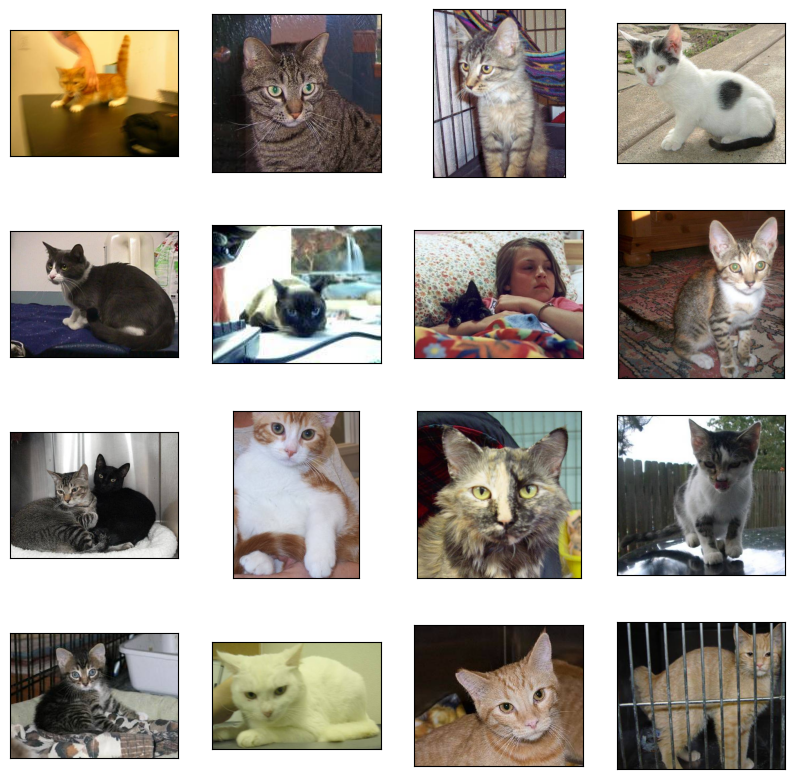

In [ ]:
# Imagens de Gatos
plt.figure(figsize=(10, 10))
for i in range(16):
  ax = plt.subplot(4, 4, i + 1)
  filename = train_cats_dir + '/cat.' + str(i) + '.jpg'
  image = imread(filename)
  plt.imshow(image)
  ax.get_xaxis().set_visible(False)
  ax.get_yaxis().set_visible(False)
plt.show()

## Treinamento do Modelo (camadas finais)


## Data Evaluation

In [ ]:
val_datagen = ImageDataGenerator(rescale=1./255)
gera = val_datagen.flow_from_directory(
        train_dir,
        target_size=(299, 299),
        batch_size=20,
        shuffle=False,
        seed=0,
        class_mode='categorical')

encoding = modelo4.predict(gera)


from sklearn.decomposition import PCA, KernelPCA
from sklearn.manifold import TSNE

Found 2000 images belonging to 2 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


100/100 ━━━━━━━━━━━━━━━━━━━━ 20s 89ms/step


## PCA

Aplicando PCA

In [ ]:
# Trabalhando com PCA

from sklearn.decomposition import PCA

# As representações em 'encoding" - uma matriz onde linha é imagem e coluna é uma característica
pca = PCA(n_components=2)
Xpca = pca.fit_transform(encoding)

Plotação PCA

['cats', 'dogs']


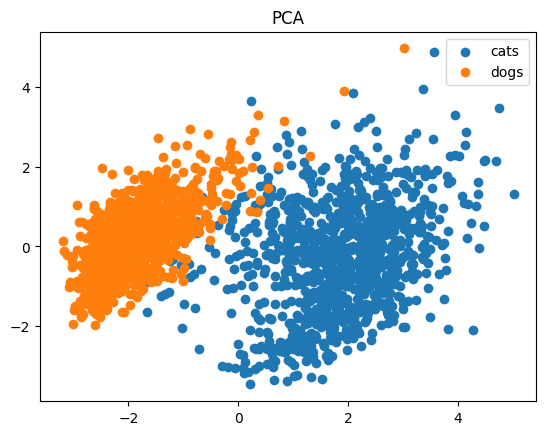

In [ ]:
# Rótulos para as classes
labels = list(gera.class_indices.keys())
print(labels)

# Plotagem do gráfico de dispersão
fig, ax = plt.subplots()
for i in range(np.max(gera.labels) + 1):
    idx = gera.labels == i
    ax.scatter(Xpca[idx, 0], Xpca[idx, 1], label=labels[i])

# Adiciona legendas e exibe o gráfico
ax.legend()
plt.title('PCA')
plt.show()

In [ ]:
print("Explained Variance:", np.sum(pca.explained_variance_ratio_))
print(Xpca.shape)

Explained Variance: 0.20361857
(2000, 2)


# TSNE

Aplicando TSNE

In [ ]:
# Trabalhando com TSNE

from sklearn.manifold import TSNE

# Configurando t-SNE com parâmetros
tsne = TSNE(n_components=2, learning_rate=200, n_iter=1000)

# Aplicar o t-SNE nos dados
Xtsne = tsne.fit_transform(encoding)


/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


Plotação TSNE

['cats', 'dogs']


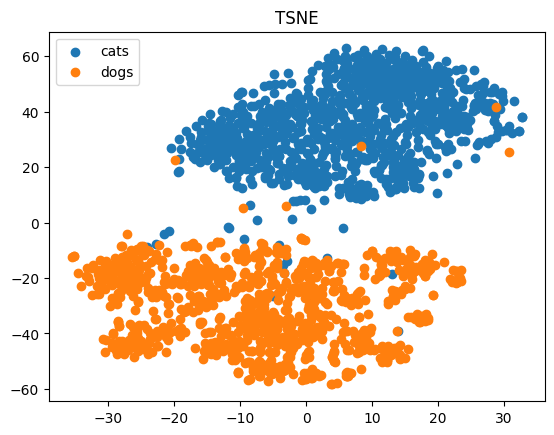

In [ ]:
# Rótulos para as classes
labels = list(gera.class_indices.keys())
print(labels)

# Plotagem do gráfico de dispersão
fig, ax = plt.subplots()
for i in range(np.max(gera.classes) + 1):
    idx = gera.classes == i
    ax.scatter(Xtsne[idx, 0], Xtsne[idx, 1], label=labels[i])

# Adicionar legendas e exibir o gráfico
ax.legend()
plt.title('TSNE')
plt.show()